In [1]:
import glob
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.dates as mdates

RESULTS_DIR = "/Users/jcreest/Documents/FRESH-CARE/WP1/data/luq_new/"
TAU_DAYS = 5      
R_KM = 10         

def extract_case_study_abbr(filename):
    filename_upper = filename.upper()
    if "BERING" in filename_upper or "BST" in filename_upper:
        return "BST"
    elif "MED" in filename_upper or "MEDITERRANEAN" in filename_upper:
        return "MED"
    return ""

def load_luq_csv_results_fixed(results_dir):
    results_path = Path(results_dir)
    csv_files = list(results_path.glob("luq_results_drifter_*.csv"))
    
    if not csv_files:
        print(f"CSV files not found in: {results_dir}")
        return {}

    drifters_data = {}
    for csv_file in csv_files:
        try:
            df = pd.read_csv(csv_file, sep=";", na_values=["", "NA", "NaN"])
            if df.empty:
                continue
            
            raw_filename = str(df["drifter_filename"].dropna().iloc[0])
            filename_stem = Path(raw_filename).stem  # Treu l'extensió (ex: 'drifter_3')
            
            # Find case study abbreviation and create drifter key
            abbr = extract_case_study_abbr(raw_filename)
            if not abbr:
                abbr = extract_case_study_abbr(csv_file.name)
            
            if abbr and not filename_stem.startswith(abbr):
                drifter_key = f"{abbr}_{filename_stem}"
            else:
                drifter_key = filename_stem
            
            summary_df = df[df["data_type"] == "summary"].copy()
            timeseries_df = df[df["data_type"] == "timeseries"].copy()
            
            if not timeseries_df.empty:
                timeseries_df["t0_datetime"] = pd.to_datetime(timeseries_df["t0_datetime"])

            # Save and concatenate processed data
            if drifter_key in drifters_data:
                drifters_data[drifter_key]["timeseries"] = pd.concat(
                    [drifters_data[drifter_key]["timeseries"], timeseries_df]
                ).drop_duplicates(subset=["dataset", "r_km", "tau_days", "t0_datetime"])
            else:
                metadata = {
                    "filename": raw_filename,
                    "L_characteristic_km": summary_df["L_characteristic_km"].iloc[0] if not summary_df.empty else np.nan,
                }
                drifters_data[drifter_key] = {
                    "summary": summary_df,
                    "timeseries": timeseries_df,
                    "metadata": metadata,
                }
        except Exception as e:
            print(f"Error processing file {csv_file.name}: {e}")
            continue

    print(f"Drifters loaded: {list(drifters_data.keys())}")
    return drifters_data

drifters_data = load_luq_csv_results_fixed(RESULTS_DIR)

Drifters loaded: ['300234062954450', 'BST_300234063229590', '300234065800000', '145901', '300534060314460', '145931', '300234063253890', '300234066217780']


In [2]:
import re
from pathlib import Path
import pandas as pd
import numpy as np

drifters_config = {
    "BST": {"id": "300234063229590", "name": "Bering Strait", "type": "date", "start": "04-10-2016", "days": 30}, #0
    "LFG": {"id": "300234066217780", "name": "Lofoten Gyre", "type": "date", "start": "09-09-2021", "days": 30}, #1
    "WSC": {"id": "145931", "name": "West Spitsbergen Current", "type": "iloc", "start": 160, "days": 30}, #2
    "EGC": {"id": "300234063253890", "name": "East Greenland Current", "type": "date", "start": "30-05-2017", "days": 60}, #3
    "BSO": {"id": "145901", "name": "Barents Sea Opening", "type": "iloc", "start": 130, "days": 60}, #4
    "BEA": {"id": "300534060314460", "name": "Beaufort Gyre", "type": "date", "start": "01-09-2020", "days": 60}, #5
    "GST": {"id": "300234062954450", "name": "Gulf Stream", "type": "iloc", "start": 300, "days": 150}, #6
    "LBC": {"id": "300234062954450", "name": "Labrador Current", "type": "iloc", "start": 30, "days": 150}, #7
    "TPD": {"id": "300234065800000", "name": "Transpolar Drift Stream", "type": "iloc", "start": 30, "days": 150} #8
}

def identify_case_study_by_id(csv_name, drifters_config):
    csv_name_str = str(csv_name)
    
    match = re.search(r"drifter_(\d+)", csv_name_str)
    if not match:
        return None
    
    file_id = match.group(1)
    
    # Shared ID for Gulf Stream and Labrador Current
    if file_id == "300234062954450":
        if "2015" in csv_name_str:
            return "LBC"  # 2015 trajectory corresponds to Labrador Current
        elif "2016" in csv_name_str:
            return "GST"  # 2016 trajectory corresponds to Gulf Stream Current
    
    # Remaining drifters
    for case_code, conf in drifters_config.items():
        if str(conf["id"]) == file_id:
            return case_code
            
    return None

def load_luq_csv_results_by_case(results_dir, drifters_config):
    results_path = Path(results_dir)
    csv_files = list(results_path.glob("luq_results_drifter_*.csv"))
    
    if not csv_files:
        print(f"No CSV files found in: {results_dir}")
        return {}

    drifters_data = {}
    for csv_file in csv_files:
        try:
            # Identify case study by ID
            case_code = identify_case_study_by_id(csv_file.name, drifters_config)
            
            if not case_code:
                print(f"No case study in {csv_file.name}. Skipping...")
                continue
            
            df = pd.read_csv(csv_file, sep=";", na_values=["", "NA", "NaN"])
            if df.empty:
                continue
            
            raw_filename = str(df["drifter_filename"].dropna().iloc[0]) if "drifter_filename" in df.columns else csv_file.name
            summary_df = df[df["data_type"] == "summary"].copy()
            timeseries_df = df[df["data_type"] == "timeseries"].copy()
            
            if not timeseries_df.empty:
                timeseries_df["t0_datetime"] = pd.to_datetime(timeseries_df["t0_datetime"])

            # Save using abbr
            if case_code in drifters_data:
                drifters_data[case_code]["timeseries"] = pd.concat(
                    [drifters_data[case_code]["timeseries"], timeseries_df]
                ).drop_duplicates(subset=["dataset", "r_km", "tau_days", "t0_datetime"])
            else:
                metadata = {
                    "filename": raw_filename,
                    "L_characteristic_km": summary_df["L_characteristic_km"].iloc[0] if not summary_df.empty else np.nan,
                }
                drifters_data[case_code] = {
                    "summary": summary_df,
                    "timeseries": timeseries_df,
                    "metadata": metadata,
                }
        except Exception as e:
            print(f"Error loading {csv_file.name}: {e}")
            continue

    print(f"Case studies loaded correctly: {list(drifters_data.keys())}")
    return drifters_data

RESULTS_DIR = "/Users/jcreest/Documents/FRESH-CARE/WP1/data/luq_new/"
drifters_data = load_luq_csv_results_by_case(RESULTS_DIR, drifters_config)

Case studies loaded correctly: ['LBC', 'BST', 'TPD', 'BSO', 'BEA', 'WSC', 'GST', 'EGC', 'LFG']


In [3]:
def plot_luq_smart(drifters_data, case_code, tau_days=5, r_km=10, f_title=None):
    if case_code not in drifters_data:
        print(f"Case {case_code} is not available.")
        return

    # color config
    colors = {'AVISO': 'orange', 'GLOBCURRENT': 'green', 'OSCAR': 'magenta', 'NEUROST': 'cyan', 'GLORYS': 'blue', 'TOPAZ': 'red'}
    dataset_order = ['AVISO', 'GLOBCURRENT', 'OSCAR', 'NEUROST', 'GLORYS', 'TOPAZ']

    timeseries_df = drifters_data[case_code]["timeseries"]
    filtered_df = timeseries_df[(timeseries_df["tau_days"] == tau_days) & (timeseries_df["r_km"] == r_km)].copy()
    filtered_df["dataset"] = filtered_df["dataset"].replace({"ADT-0.25": "AVISO", "OSCAR-geos": "OSCAR"})

    if filtered_df.empty:
        print(f"No files for: {case_code}")
        return

    col_to_plot = "luq_normalized"
    title_label = "LUQ Normalized Mean"
    if filtered_df["luq_normalized"].notna().sum() == 0:
        col_to_plot = "valid_frac"
        title_label = "Valid Fraction"

    fig, ax = plt.subplots(figsize=(11, 5))

    # Iteration
    available_here = [d for d in dataset_order if d in filtered_df["dataset"].values]
    
    for dataset_name in available_here:
        dataset_df = filtered_df[filtered_df["dataset"] == dataset_name].sort_values("t0_datetime")
        ax.plot(
            dataset_df["t0_datetime"], dataset_df[col_to_plot],
            color=colors.get(dataset_name, "black"), label=dataset_name, 
            linewidth=2.0, marker='o', markersize=4
        )

    ax.set_xlabel("Time (t₀)", fontsize=15)
    ax.set_ylabel(title_label, fontsize=15)
    ax.set_title(f_title if f_title else f"Case Study: {case_code}")
    ax.legend(fontsize=13, loc="best") # Surt automàticament ordenat de dalt a baix
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    fig.savefig(f"{case_code}_timeseries.png", dpi=300)
    plt.show()

In [3]:
def plot_luq_case_studies_matrix(drifters_data, case_codes, drifters_config, tau_days=5, r_km=10, save_name="matrix.png"):
    n_cases = len(case_codes)
    if n_cases == 0:
        return

    colors = {
        'AVISO': 'orange', 
        'GLOBCURRENT': 'green', 
        'OSCAR': 'magenta', 
        'NEUROST': 'cyan', 
        'GLORYS': 'blue', 
        'TOPAZ': 'red'
    }

    dataset_order = ['AVISO', 'GLOBCURRENT', 'OSCAR', 'NEUROST', 'GLORYS', 'TOPAZ']

    fig, axes = plt.subplots(n_cases, 1, figsize=(12, 3.8 * n_cases), sharex=False, constrained_layout=True)
    if n_cases == 1:
        axes = [axes]

    global_handles = {}

    for idx, code in enumerate(case_codes):
        ax = axes[idx]
        title_str = drifters_config[code]["name"] if code in drifters_config else code

        if code not in drifters_data:
            ax.text(0.5, 0.5, f"Case {code} not available in CSVs", transform=ax.transAxes, ha='center', va='center', fontsize=14)
            continue

        timeseries_df = drifters_data[code]["timeseries"]
        filtered_df = timeseries_df[(timeseries_df["tau_days"] == tau_days) & (timeseries_df["r_km"] == r_km)].copy()
        filtered_df["dataset"] = filtered_df["dataset"].replace({"ADT-0.25": "AVISO", "OSCAR-geos": "OSCAR"})

        if filtered_df.empty:
            ax.text(0.5, 0.5, f"No data for tau={tau_days}d, r={r_km}km", transform=ax.transAxes, ha='center', va='center', fontsize=12)
            continue

        col_to_plot = "luq_normalized"
        ylabel_str = "Normalized LUQ [-]"
        if filtered_df["luq_normalized"].notna().sum() == 0:
            col_to_plot = "valid_frac"
            ylabel_str = "Valid Fraction [-]"

        available_here = [d for d in dataset_order if d in filtered_df["dataset"].values]

        for dataset_name in available_here:
            dataset_df = filtered_df[filtered_df["dataset"] == dataset_name].sort_values("t0_datetime")
            line, = ax.plot(
                dataset_df["t0_datetime"], dataset_df[col_to_plot],
                color=colors.get(dataset_name, "black"), linewidth=1.5,
                alpha=0.85, marker='o', markersize=3)
            # Save handle
            if dataset_name not in global_handles:
                global_handles[dataset_name] = line

        ax.set_ylabel(ylabel_str, fontsize=12, fontweight='bold')
        ax.set_title(f"{chr(97+idx)}) {title_str} ({code})", fontsize=14, fontweight='bold', loc='left', pad=6)
        ax.grid(True, alpha=0.25, linestyle="--")
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(axis='both', labelsize=11)
        
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        plt.setp(ax.get_xticklabels(), rotation=15, ha='right')

    ordered_labels = [d for d in dataset_order if d in global_handles]
    ordered_handles = [global_handles[label] for label in ordered_labels]
    
    fig.legend(ordered_handles, ordered_labels, loc='upper center', bbox_to_anchor=(0.5, 1.03),
               ncol=len(ordered_labels), fontsize=12, frameon=True, facecolor='white', edgecolor='none')

    fig.suptitle(f"$\\tau$ = {tau_days} days, $R$ = {r_km} km", fontsize=15, fontweight='bold', y=1.05)
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    print(f"Saved in: {save_name}")
    plt.show()

Saved in: luq_matrix_30_days.png


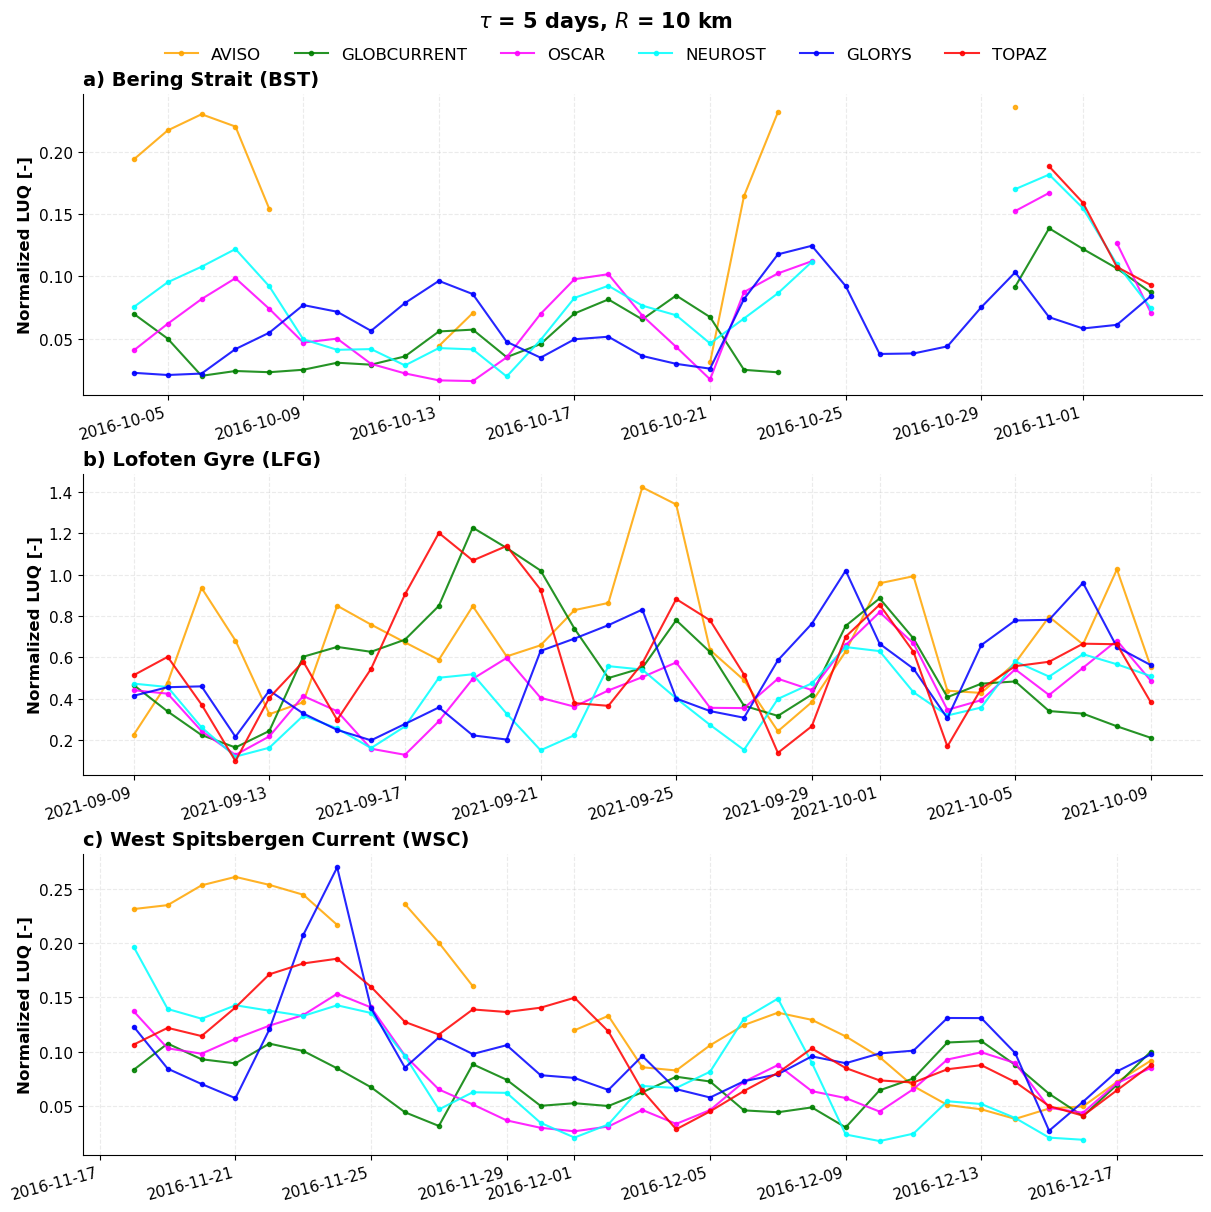

Saved in: luq_matrix_60_days.png


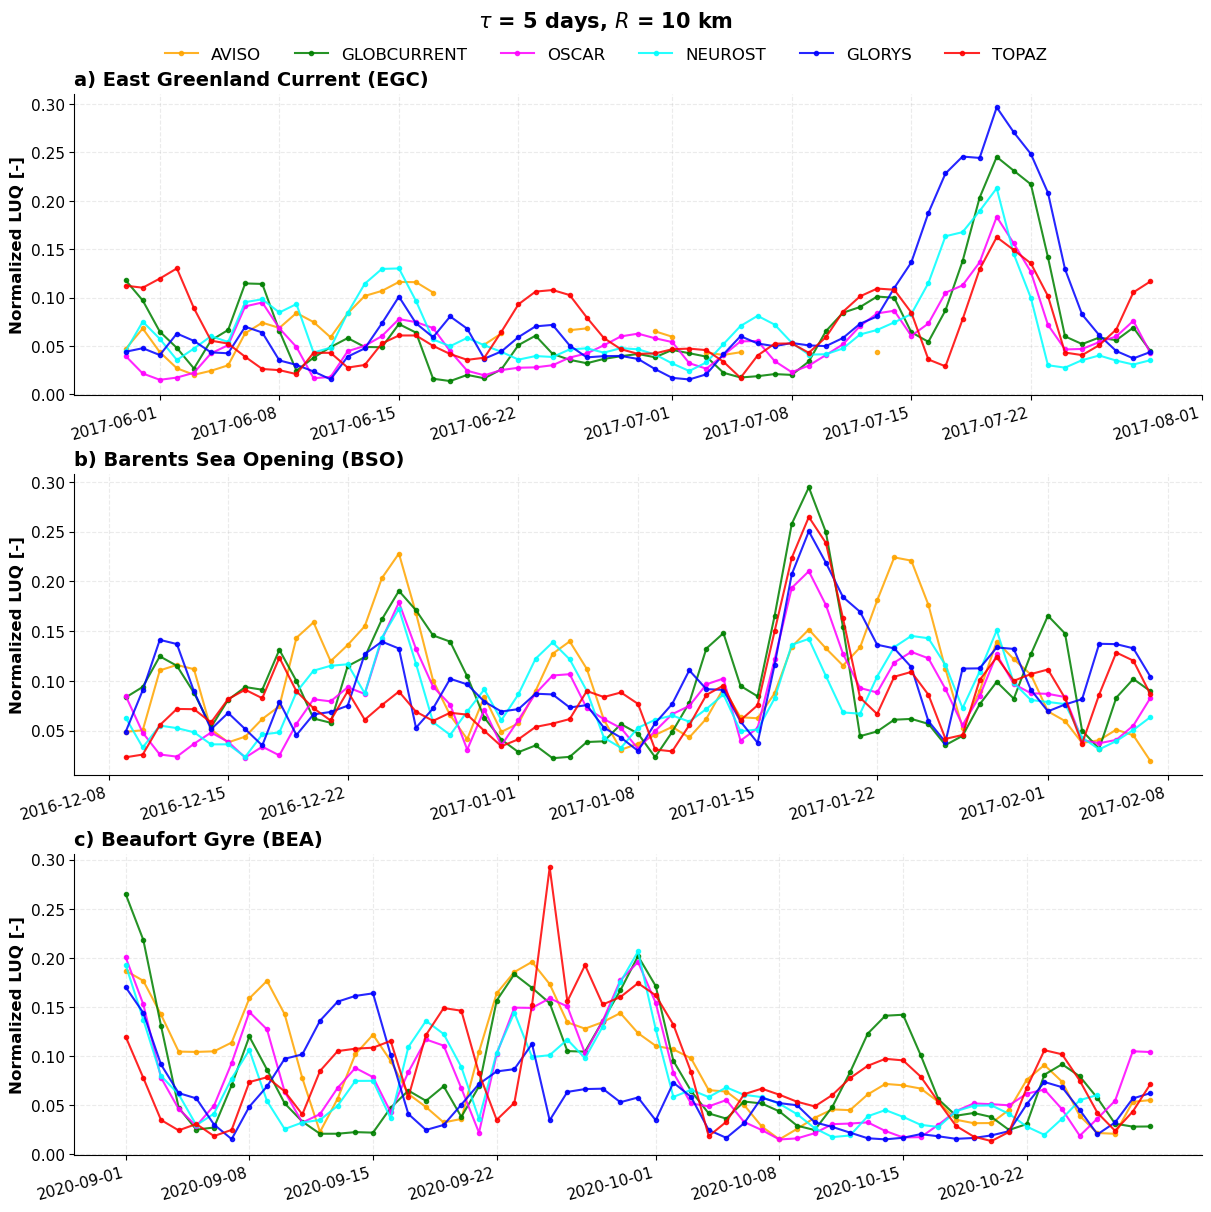

Saved in: luq_matrix_150_days.png


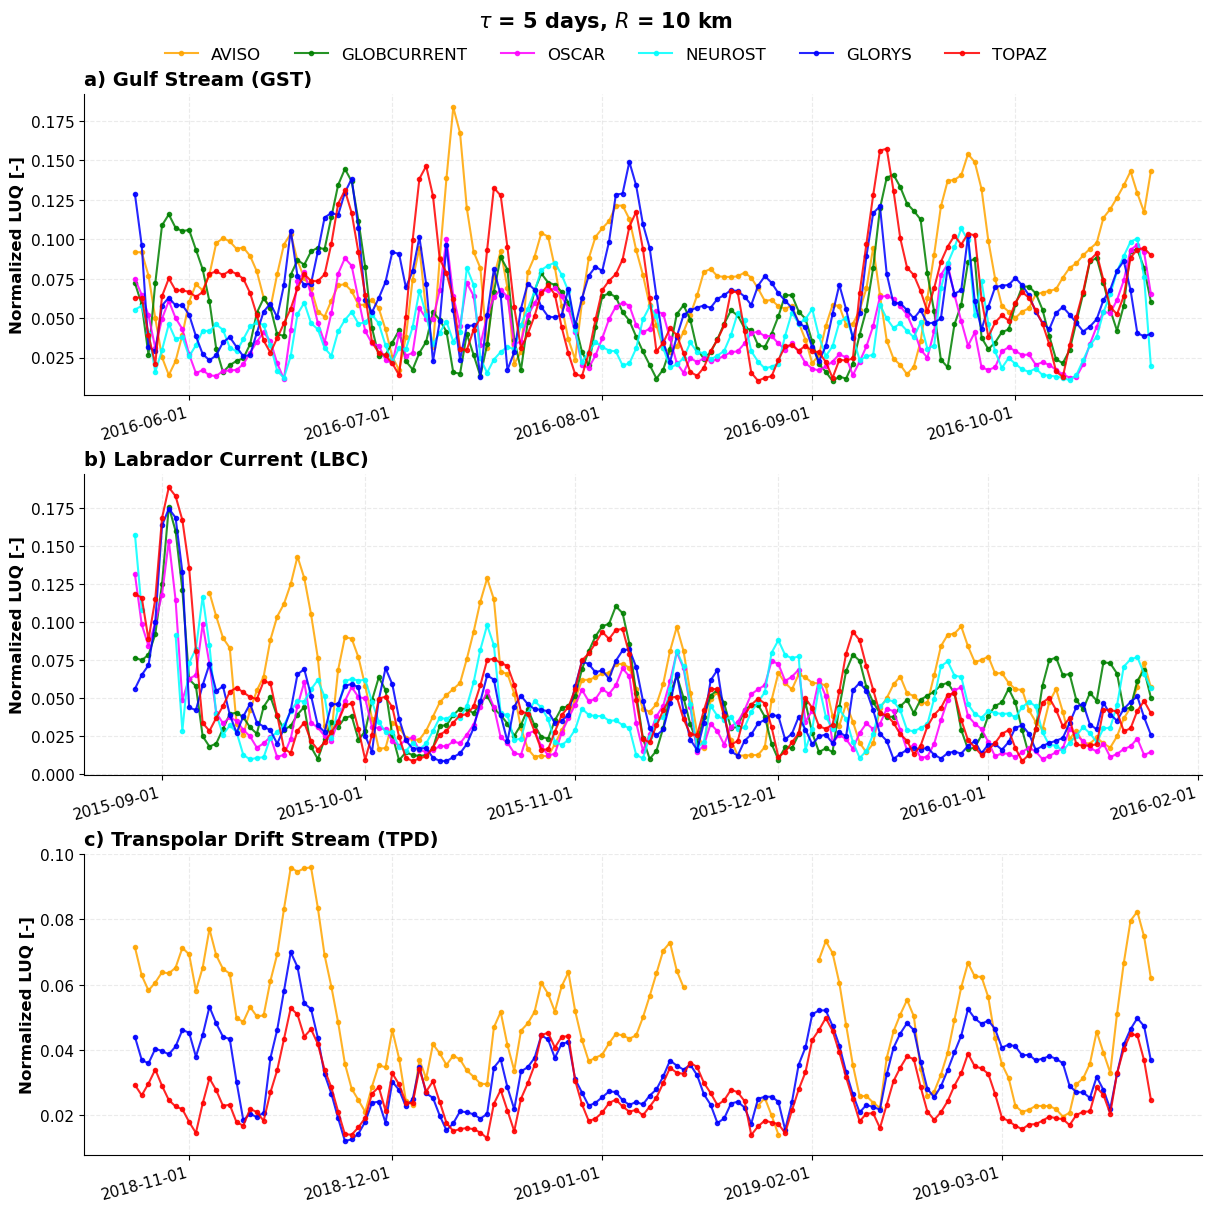

In [4]:
# Groups according to case study duration
cases_30_days = [code for code, conf in drifters_config.items() if conf["days"] == 30]
cases_60_days = [code for code, conf in drifters_config.items() if conf["days"] == 60]
cases_150_days = [code for code, conf in drifters_config.items() if conf["days"] == 150]

# Chosen parameters
TAU_DAYS = 5
R_KM = 10

# Matrix for 30-day cases
plot_luq_case_studies_matrix(
    drifters_data, 
    case_codes=cases_30_days, 
    drifters_config=drifters_config,
    tau_days=TAU_DAYS, r_km=R_KM, 
    save_name="luq_matrix_30_days.png"
)

# Matrix for 60-day cases
plot_luq_case_studies_matrix(
    drifters_data, 
    case_codes=cases_60_days, 
    drifters_config=drifters_config,
    tau_days=TAU_DAYS, r_km=R_KM, 
    save_name="luq_matrix_60_days.png"
)

# Matrix for 150-day caees
plot_luq_case_studies_matrix(
    drifters_data, 
    case_codes=cases_150_days, 
    drifters_config=drifters_config,
    tau_days=TAU_DAYS, r_km=R_KM, 
    save_name="luq_matrix_150_days.png"
)

In [5]:
def plot_luq_global_boxplot(drifters_data, drifters_config, tau_days=5, r_km=10, save_name="luq_global_comparison.png"):

    colors = {
        'AVISO': 'orange',
        'GLOBCURRENT': 'green',
        'OSCAR': 'magenta',
        'NEUROST': 'cyan',
        'GLORYS': 'blue',
        'TOPAZ': 'red'
    }
    dataset_order = ['AVISO', 'GLOBCURRENT', 'OSCAR', 'NEUROST', 'GLORYS', 'TOPAZ']
    
    order = ["BST","LFG","WSC","EGC","BSO","BEA","GST","LBC","TPD"]
    
    # Merge dataframes
    all_data = []
    for code, data in drifters_data.items():
        df_ts = data["timeseries"].copy()
        df_ts["case_code"] = code
        if code in drifters_config:
            df_ts["case_name"] = drifters_config[code]["name"]
            df_ts["duration_days"] = drifters_config[code]["days"]
        else:
            df_ts["case_name"] = code
            df_ts["duration_days"] = 0
        all_data.append(df_ts)
        
    if not all_data:
        print("No data to process")
        return
        
    global_df = pd.concat(all_data, ignore_index=True)
    
    # Clean and filter data
    global_df["dataset"] = global_df["dataset"].replace({"ADT-0.25": "AVISO", "OSCAR-geos": "OSCAR"})
    filtered_df = global_df[(global_df["tau_days"] == tau_days) & (global_df["r_km"] == r_km)].copy()
    
    if filtered_df.empty:
        print(f"No data for tau={tau_days} and r={r_km}")
        return

    filtered_df["case_code"] = pd.Categorical(filtered_df["case_code"], categories=order, ordered=True)

    col_to_plot = "luq_normalized"
    ylabel_str = "Normalized LUQ [-]"
    if filtered_df["luq_normalized"].notna().sum() == 0:
        col_to_plot = "valid_frac"
        ylabel_str = "Valid Fraction [-]"

    # Plot design
    fig, ax = plt.subplots(figsize=(12, 6))
    
    sns.boxplot(
        data=filtered_df,
        x="case_code",
        y=col_to_plot,
        hue="dataset",
        hue_order=dataset_order,
        palette=colors,
        ax=ax,
        fliersize=3,
        linewidth=1.5,
        whis=1.5,
        order=order 
    )
    
    ax.set_xlabel("Case Study", fontsize=16, fontweight='bold')
    ax.set_ylabel(ylabel_str, fontsize=15, fontweight='bold')
    ax.set_title(f"$\\tau$ = {tau_days} days, $R$ = {r_km} km", fontsize=17, fontweight='bold', pad=15)
    
    ax.grid(True, axis='y', alpha=0.3, linestyle="--")
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis='both', labelsize=14)
    
    ax.legend(fontsize=14, loc="upper right", frameon=True)
    
    plt.tight_layout()
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    print(f"Plot saved in: {save_name}")
    plt.show()

Plot saved in: luq_global_comparison_t5_r10.png


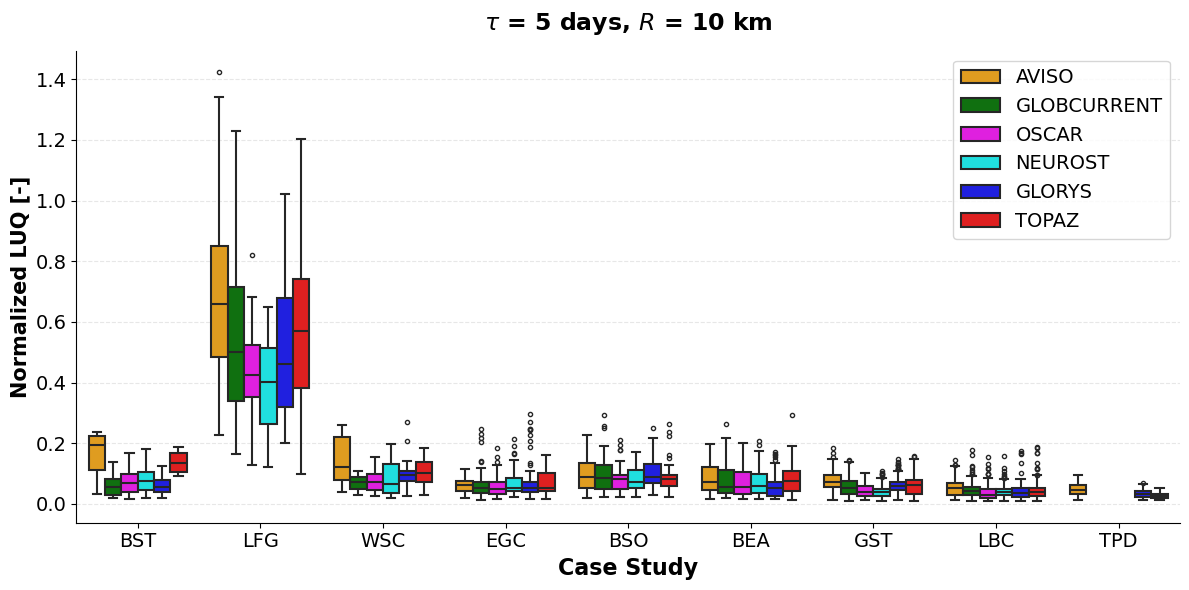

In [6]:
plot_luq_global_boxplot(drifters_data, drifters_config, tau_days=5, r_km=10, save_name="luq_global_comparison_t5_r10.png")

Plot saved in: luq_global_comparison_t10_r10.png


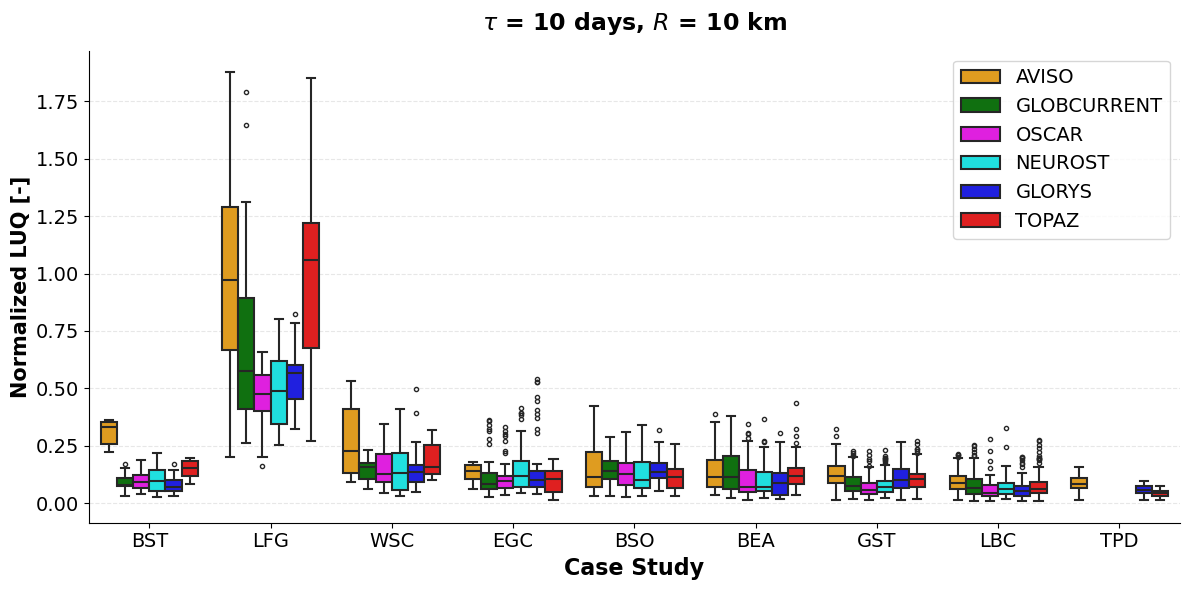

In [8]:
plot_luq_global_boxplot(drifters_data, drifters_config, tau_days=10, r_km=10, save_name="luq_global_comparison_t10_r10.png")

Plot saved in: luq_global_comparison_t5_r20.png


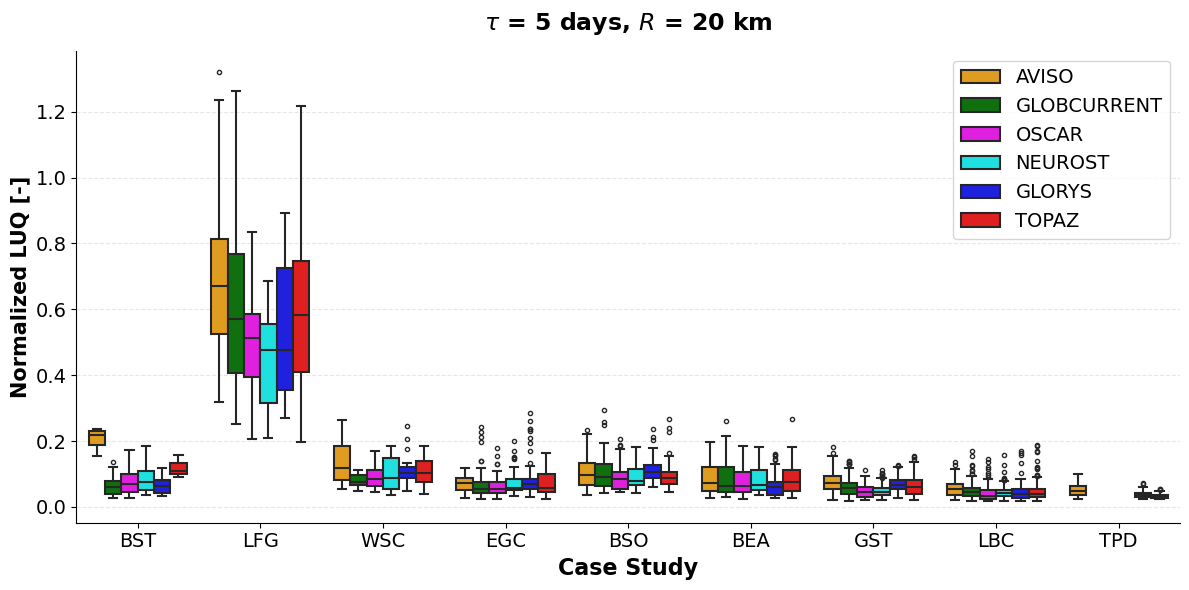

In [9]:
plot_luq_global_boxplot(drifters_data, drifters_config, tau_days=5, r_km=20, save_name="luq_global_comparison_t5_r20.png")

Plot saved in: luq_t5_r5.png


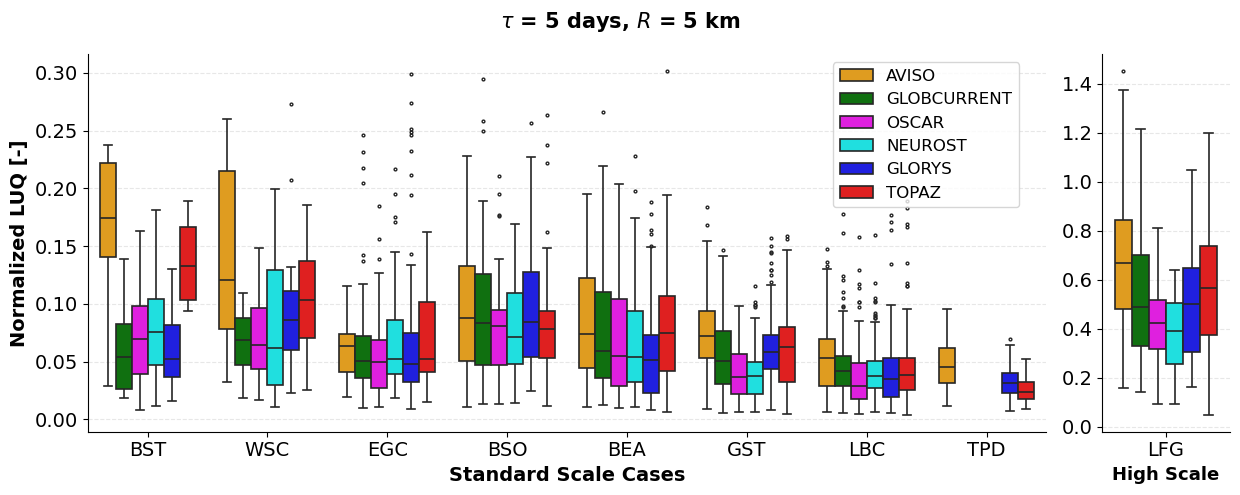

Plot saved in: luq_t5_r10.png


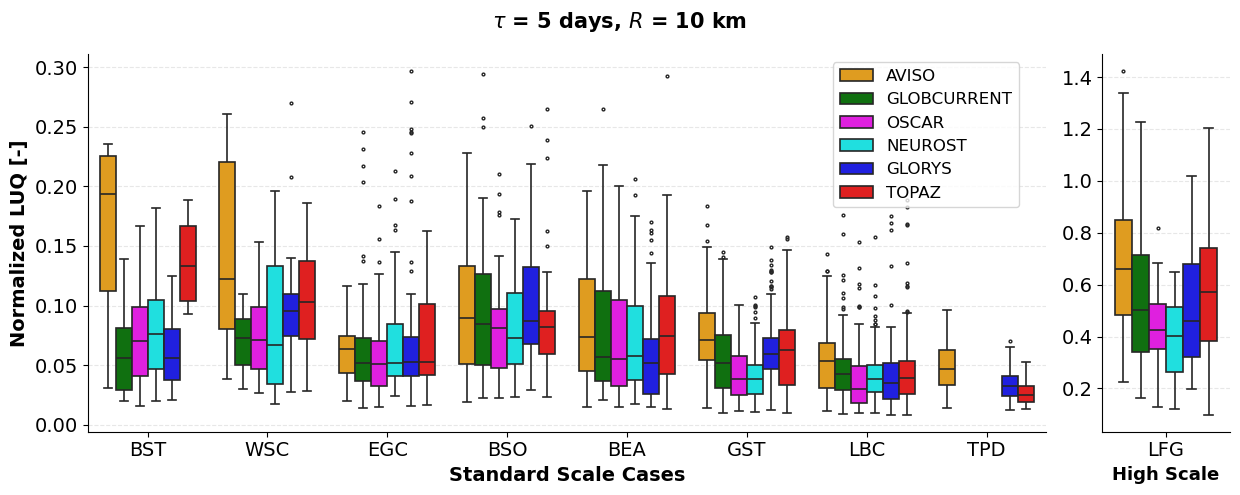

In [10]:
def plot_luq_global_boxplot_scale(drifters_data, drifters_config, tau_days=5, r_km=10, save_name="luq_global_comparison.png"):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd
    
    colors = {
        'AVISO': 'orange',
        'GLOBCURRENT': 'green',
        'OSCAR': 'magenta',
        'NEUROST': 'cyan',
        'GLORYS': 'blue',
        'TOPAZ': 'red'
    }
    dataset_order = ['AVISO', 'GLOBCURRENT', 'OSCAR', 'NEUROST', 'GLORYS', 'TOPAZ']
    
    order = ["BST","LFG","WSC","EGC","BSO","BEA","GST","LBC","TPD"]
    
    all_data = []
    for code, data in drifters_data.items():
        df_ts = data["timeseries"].copy()
        df_ts["case_code"] = code
        if code in drifters_config:
            df_ts["case_name"] = drifters_config[code]["name"]
            df_ts["duration_days"] = drifters_config[code]["days"]
        else:
            df_ts["case_name"] = code
            df_ts["duration_days"] = 0
        all_data.append(df_ts)
        
    if not all_data:
        print("No data to process")
        return
        
    global_df = pd.concat(all_data, ignore_index=True)
    
    global_df["dataset"] = global_df["dataset"].replace({"ADT-0.25": "AVISO", "OSCAR-geos": "OSCAR"})
    filtered_df = global_df[(global_df["tau_days"] == tau_days) & (global_df["r_km"] == r_km)].copy()
    
    if filtered_df.empty:
        print(f"No data for tau={tau_days} and r={r_km}")
        return

    # Force categorical order
    filtered_df["case_code"] = pd.Categorical(filtered_df["case_code"], categories=order, ordered=True)

    col_to_plot = "luq_normalized"
    ylabel_str = "Normalized LUQ [-]"
    if filtered_df["luq_normalized"].notna().sum() == 0:
        col_to_plot = "valid_frac"
        ylabel_str = "Valid Fraction [-]"

    # Separate LFG case
    order_others = [c for c in order if c != "LFG"]
    order_lfg = ["LFG"]

    # =====================================================================
    # SPLIT AXIS for Lofoten Gyre
    # =====================================================================
    fig, (ax1, ax2) = plt.subplots(
        1, 2, 
        figsize=(12.5, 5), 
        gridspec_kw={'width_ratios': [9, 1.2]}, 
        sharey=False
    )
    
    # all cases except LFG
    sns.boxplot(
        data=filtered_df, x="case_code", y=col_to_plot, hue="dataset",
        hue_order=dataset_order, palette=colors, ax=ax1, fliersize=2, linewidth=1.2, whis=1.5,
        order=order_others
    )
    ax1.set_xlabel("Standard Scale Cases", fontsize=14, fontweight='bold')
    ax1.set_ylabel(ylabel_str, fontsize=14, fontweight='bold')
    ax1.grid(True, axis='y', alpha=0.3, linestyle="--")
    ax1.spines[["top", "right"]].set_visible(False)
    ax1.tick_params(axis='both', labelsize=14)

    ax1.legend(fontsize=12, loc="upper right", frameon=True, bbox_to_anchor=(0.98, 1))
    
    # only LFG
    sns.boxplot(
        data=filtered_df, x="case_code", y=col_to_plot, hue="dataset",
        hue_order=dataset_order, palette=colors, ax=ax2, fliersize=2, linewidth=1.2, whis=1.5,
        order=order_lfg
    )
    ax2.set_xlabel("High Scale", fontsize=13, fontweight='bold')
    ax2.set_ylabel("")        # treu la cadena d'etiqueta
    ax2.grid(True, axis='y', alpha=0.3, linestyle="--")
    ax2.spines[["top", "right"]].set_visible(False)
    ax2.tick_params(axis='both', labelsize=14)
    ax2.get_legend().remove()
    
    # Unique title
    fig.suptitle(f"$\\tau$ = {tau_days} days, $R$ = {r_km} km", fontsize=15, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    print(f"Plot saved in: {save_name}")
    plt.show()

plot_luq_global_boxplot_scale(drifters_data, drifters_config, tau_days=5, r_km=5, save_name="luq_t5_r5.png")
plot_luq_global_boxplot_scale(drifters_data, drifters_config, tau_days=5, r_km=10, save_name="luq_t5_r10.png")

In [11]:
def plot_luq_sensitivity_analysis(drifters_data, drifters_config, metric_to_aggregate="luq_normalized", 
                                  group_by="tau_days", fixed_tau=5, fixed_r=10, save_name="luq_sensitivity.png"):
    """
    Oceanographic Sensitivity Plot to analyze model behavior across scales.
    Supports group_by: 'tau_days', 'r_km', or 'duration_days'.
    """
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    colors = {
        'AVISO': 'orange', 
        'GLOBCURRENT': 'green', 
        'OSCAR': 'magenta', 
        'NEUROST': 'cyan', 
        'GLORYS': 'blue', 
        'TOPAZ': 'red'
    }
    dataset_order = ['AVISO', 'GLOBCURRENT', 'OSCAR', 'NEUROST', 'GLORYS', 'TOPAZ']

    all_series = []
    for code, d_content in drifters_data.items():
        if "timeseries" in d_content and not d_content["timeseries"].empty:
            df_ts = d_content["timeseries"].copy()
            # Busquem els dies totals configurats per a aquest cas d'estudi
            duration = drifters_config[code]["days"] if code in drifters_config else np.nan
            df_ts["duration_days"] = duration
            all_series.append(df_ts)
            
    if not all_series:
        print("No data for loaded drifters.")
        return
        
    master_luq_df = pd.concat(all_series, ignore_index=True)
    
    master_luq_df["dataset"] = master_luq_df["dataset"].replace({"ADT-0.25": "AVISO", "OSCAR-geos": "OSCAR"})
    
    # Filter
    if group_by == "tau_days":
        filtered_df = master_luq_df[master_luq_df["r_km"] == fixed_r].copy()
        xlabel_str = r"Lagrangian Integration Time $\tau$ [days]"
        title_str = f"Model Sensitivity to Integration Time (Fixed Radius $R$ = {fixed_r} km)"
        
    elif group_by == "r_km":
        filtered_df = master_luq_df[master_luq_df["tau_days"] == fixed_tau].copy()
        xlabel_str = r"Search Neighborhood Radius $R$ [km]"
        title_str = f"Model Sensitivity to Spatial Radius (Fixed Time $ \tau $ = {fixed_tau} days)"
        
    elif group_by == "duration_days":
        filtered_df = master_luq_df[(master_luq_df["tau_days"] == fixed_tau) & (master_luq_df["r_km"] == fixed_r)].copy()
        xlabel_str = "Case Study Trajectory Length [days]"
        title_str = f"Sensitivity to Experiment Duration (Fixed $\tau$ = {fixed_tau} d, $R$ = {fixed_r} km)"
        
    else:
        raise ValueError("group_by ha de ser 'tau_days', 'r_km' o 'duration_days'")

    if filtered_df.empty:
        print(f"No data")
        return

    if filtered_df[metric_to_aggregate].notna().sum() == 0:
        print(f"ℹ️ '{metric_to_aggregate}' està buit. Canviem automàticament a 'valid_frac'.")
        metric_to_aggregate = "valid_frac"
        
    ylabel_str = "Mean LUQ [-]" if metric_to_aggregate == "luq_normalized" else "Mean Valid Fraction [-]"

    summary_stats = filtered_df.groupby(['dataset', group_by])[metric_to_aggregate].agg(['mean', 'sem']).reset_index()

    # Plots
    fig, ax = plt.subplots(figsize=(10, 6))
    
    for dataset_name in dataset_order:
        if dataset_name not in summary_stats['dataset'].values:
            continue
            
        ds_data = summary_stats[summary_stats['dataset'] == dataset_name].sort_values(group_by)
        
        if ds_data.empty:
            continue
            
        color_plot = colors.get(dataset_name, 'black')
        
        ax.plot(
            ds_data[group_by], ds_data['mean'], 
            marker='s', markersize=6, lw=2.5,
            color=color_plot, label=dataset_name
        )
        
        if not ds_data['sem'].isna().all():
            ax.fill_between(
                ds_data[group_by], 
                ds_data['mean'] - ds_data['sem'].fillna(0), 
                ds_data['mean'] + ds_data['sem'].fillna(0), 
                color=color_plot, alpha=0.12
            )

    ax.set_xlabel(xlabel_str, fontsize=13, fontweight='bold')
    ax.set_ylabel(ylabel_str, fontsize=13, fontweight='bold')
    ax.set_title(title_str, fontsize=14, fontweight='bold', pad=12)
    
    if group_by == "duration_days":
        ax.set_xticks([30, 60, 150])
    
    ax.grid(True, alpha=0.25, linestyle="--")
    ax.legend(fontsize=11, loc="best", frameon=True, facecolor='white', edgecolor='none')
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(axis='both', labelsize=11)
    
    plt.tight_layout()
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    print(f"Plot saved in: {save_name}")
    plt.show()

Plot saved in: sensitivity_vs_tau.png


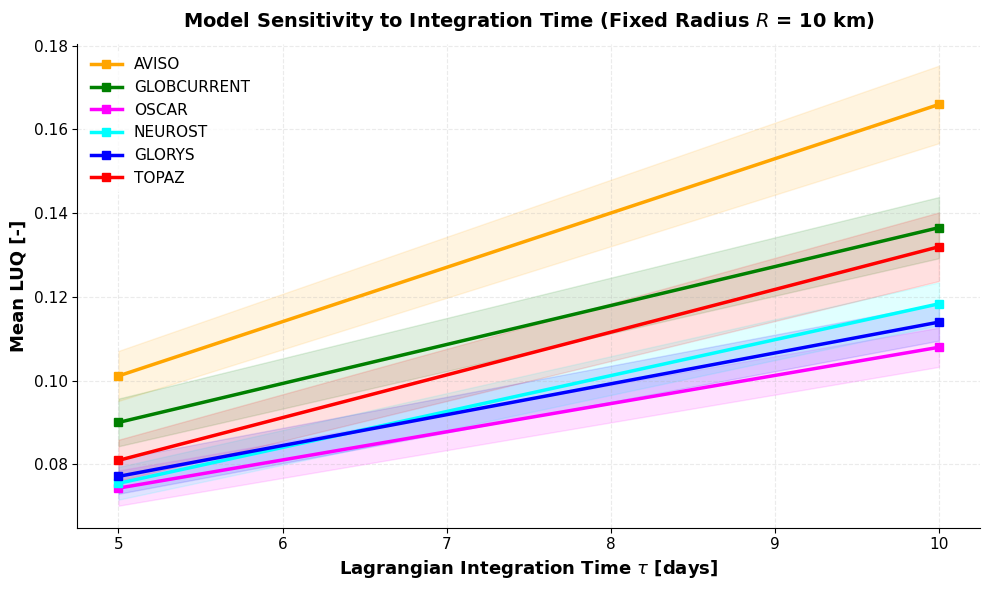

In [12]:
plot_luq_sensitivity_analysis(
    drifters_data, drifters_config,
    group_by="tau_days", 
    fixed_r=10, 
    save_name="sensitivity_vs_tau.png"
)

Plot saved in: sensitivity_vs_radius.png


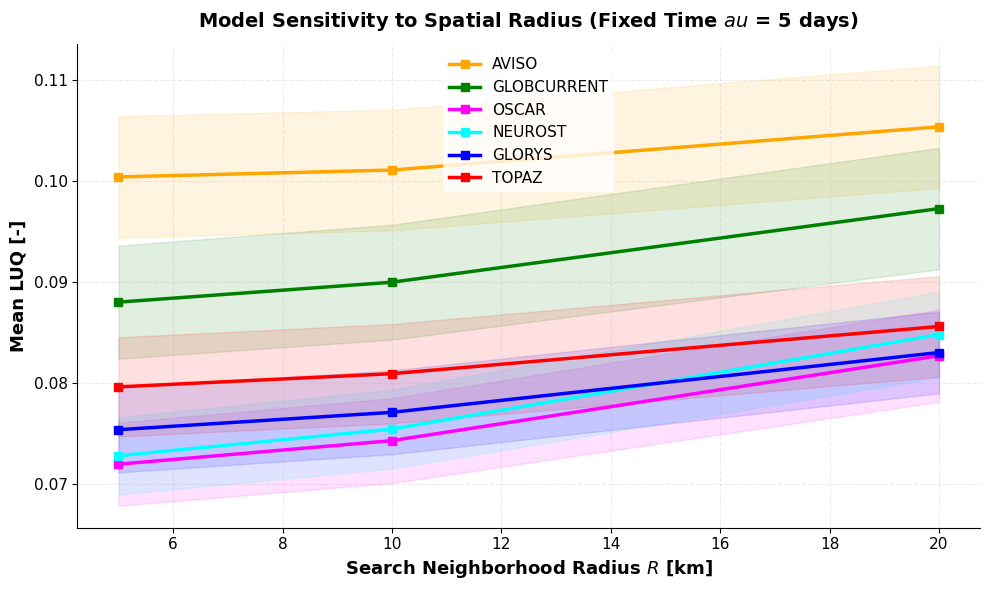

In [13]:
plot_luq_sensitivity_analysis(
    drifters_data, drifters_config,
    group_by="r_km", 
    fixed_tau=5, 
    save_name="sensitivity_vs_radius.png"
)

Plot saved in: sensitivity_vs_trajectory_length.png


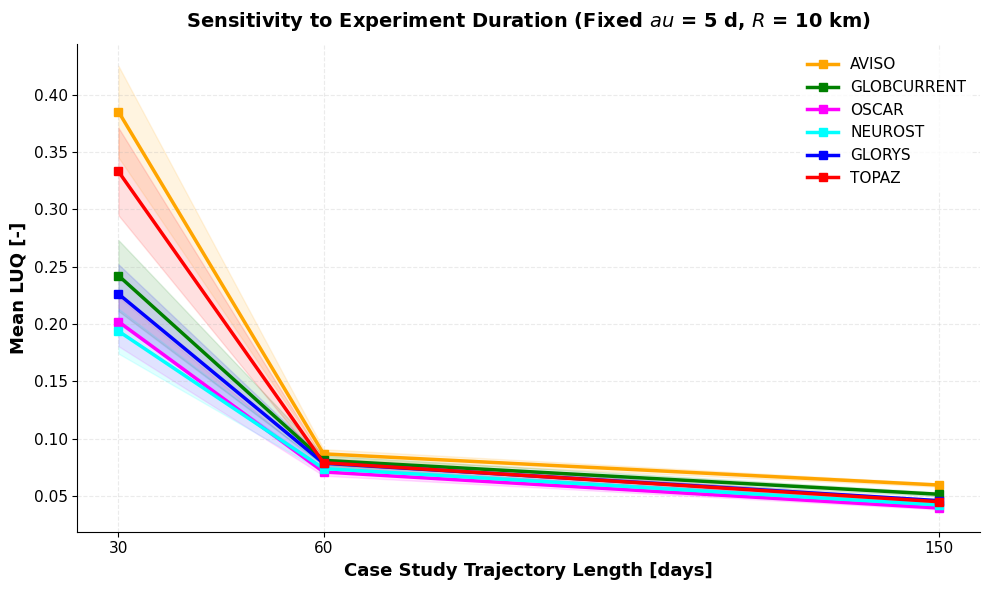

In [14]:
plot_luq_sensitivity_analysis(
    drifters_data, drifters_config,
    group_by="duration_days", 
    fixed_tau=5, 
    fixed_r=10, 
    save_name="sensitivity_vs_trajectory_length.png"
)

In [15]:
def plot_luq_optimization_per_case(drifters_data, drifters_config, case_code, metric_to_aggregate="luq_normalized"):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    colors = {
        'AVISO': 'orange', 
        'GLOBCURRENT': 'green', 
        'OSCAR': 'magenta', 
        'NEUROST': 'cyan', 
        'GLORYS': 'blue', 
        'TOPAZ': 'red'
    }
    dataset_order = ['AVISO', 'GLOBCURRENT', 'OSCAR', 'NEUROST', 'GLORYS', 'TOPAZ']

    if case_code not in drifters_data:
        print(f"Case study {case_code} not available.")
        return

    df_case = drifters_data[case_code]["timeseries"].copy()
    df_case["dataset"] = df_case["dataset"].replace({"ADT-0.25": "AVISO", "OSCAR-geos": "OSCAR"})
    
    if df_case[metric_to_aggregate].notna().sum() == 0:
        print(f"'{metric_to_aggregate}' is empty for {case_code}")
        metric_to_aggregate = "valid_frac"
        
    ylabel_str = "Mean LUQ [-]" if metric_to_aggregate == "luq_normalized" else "Mean Valid Fraction [-]"
    case_name = drifters_config[case_code]["name"] if case_code in drifters_config else case_code

    available_radii = sorted(df_case["r_km"].unique())
    n_radii = len(available_radii)

    if n_radii == 0:
        print(f"No R (r_km) valids for {case_code}")
        return
        
    summary_stats = df_case.groupby(['dataset', 'r_km', 'tau_days'])[metric_to_aggregate].mean().reset_index()

    fig, axes = plt.subplots(n_radii, 1, figsize=(10, 3.5 * n_radii), sharex=True, constrained_layout=True)
    if n_radii == 1:
        axes = [axes]

    for idx, r_val in enumerate(available_radii):
        ax = axes[idx]
        df_r = summary_stats[summary_stats["r_km"] == r_val]
        
        for dataset_name in dataset_order:
            df_ds = df_r[df_r["dataset"] == dataset_name].sort_values("tau_days")
            
            if df_ds.empty:
                continue
                
            ax.plot(
                df_ds["tau_days"], df_ds[metric_to_aggregate],
                color=colors.get(dataset_name, 'black'),
                marker='o', markersize=5, lw=2, label=dataset_name
            )
            
        ax.set_ylabel(ylabel_str, fontsize=11, fontweight='bold')
        ax.set_title(f"Search Radius $R$ = {r_val} km", fontsize=12, fontweight='bold', loc='left')
        ax.grid(True, alpha=0.25, linestyle="--")
        ax.spines[["top", "right"]].set_visible(False)
        
        if idx == 0:
            ax.legend(fontsize=10, loc="best", frameon=True, facecolor='white', edgecolor='none')

    axes[-1].set_xlabel(r"Lagrangian Integration Time $\tau$ [days]", fontsize=12, fontweight='bold')
    
    available_taus = sorted(df_case["tau_days"].unique())
    axes[-1].set_xticks(available_taus)
    
    fig.suptitle(f"Optimization Analysis: {case_name} ({case_code})", fontsize=15, fontweight='bold', y=1.02)
    
    save_name = f"optimization_{case_code}.png"
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    print(f"{case_code} optim. saved in: {save_name}")
    plt.show()

LFG optim. saved in: optimization_LFG.png


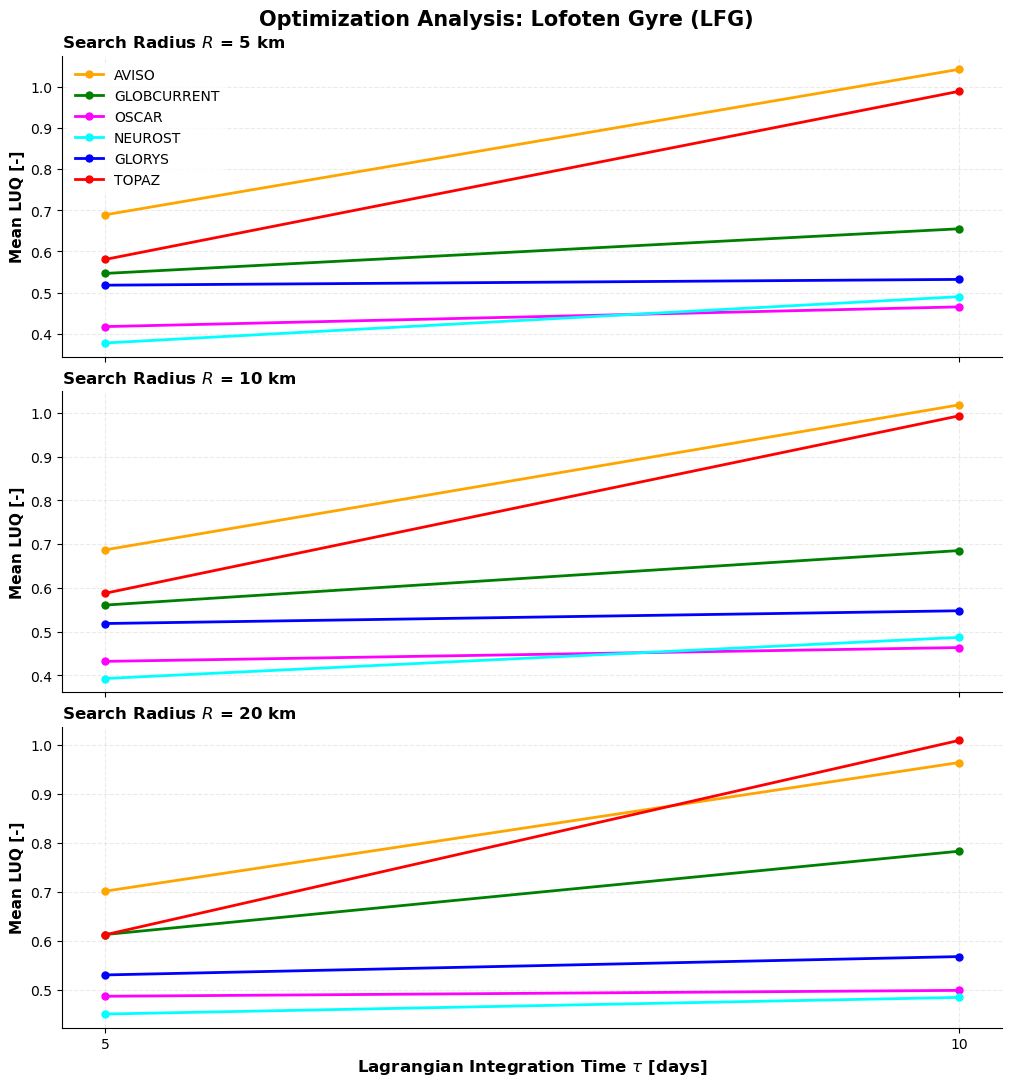

GST optim. saved in: optimization_GST.png


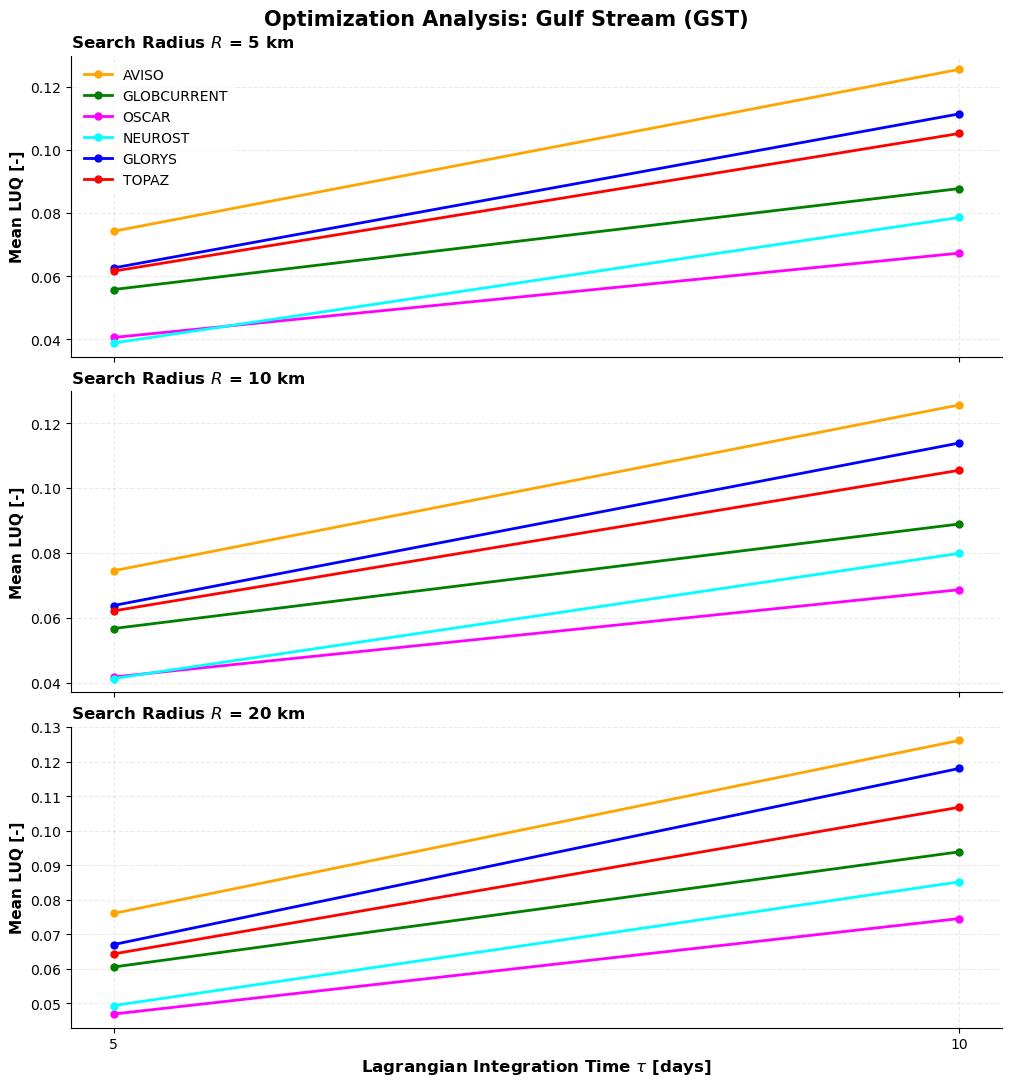

In [16]:
#BST
plot_luq_optimization_per_case(drifters_data, drifters_config, case_code="LFG")

# GST
plot_luq_optimization_per_case(drifters_data, drifters_config, case_code="GST")

Super matrix saved in: luq_global_optimization.png


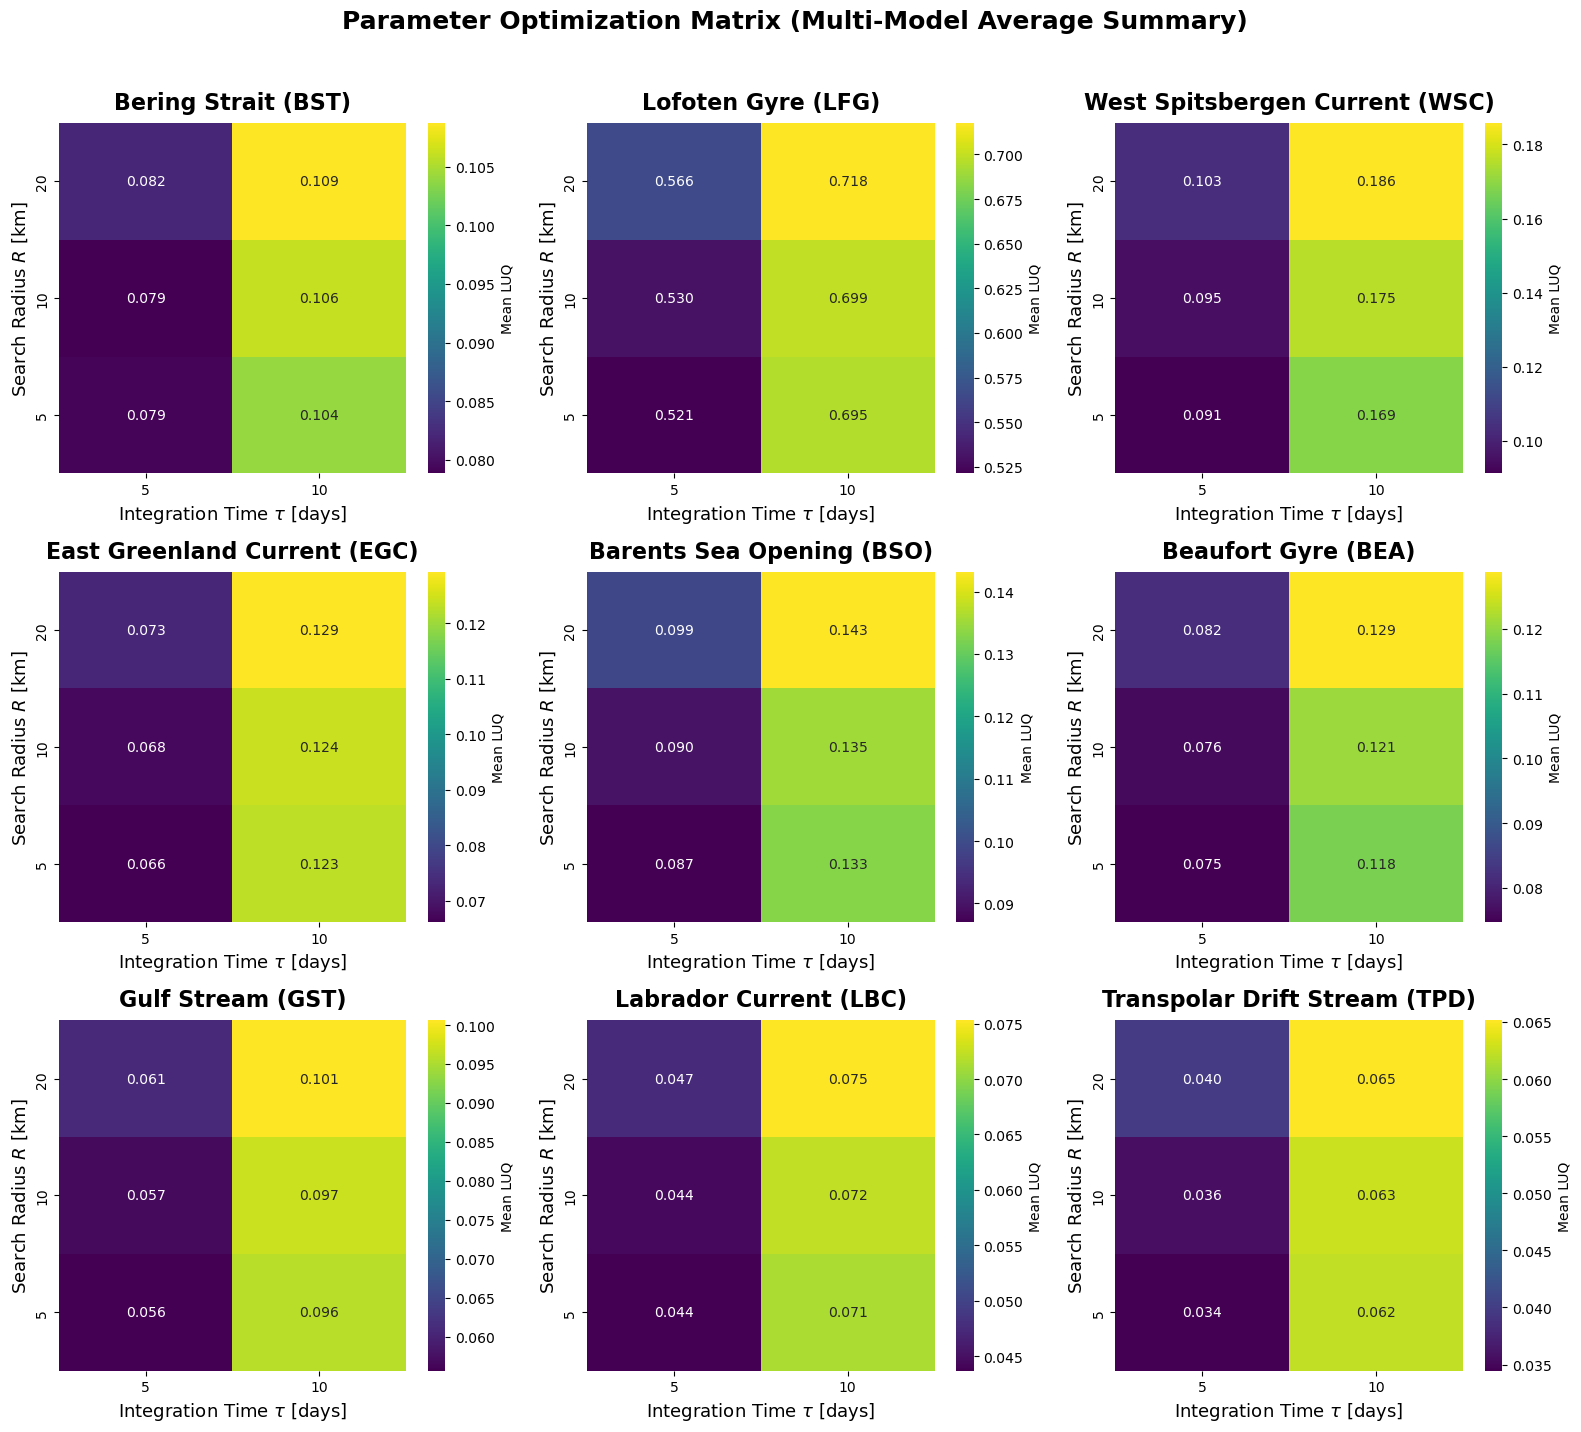

In [17]:
def plot_luq_global_optimization_heatmap(drifters_data, drifters_config, metric_to_aggregate="luq_normalized", save_name="luq_global_optimization.png"):

    import numpy as np
    import pandas as pd
    import seaborn as sns
    import matplotlib.pyplot as plt

    case_codes = ['BST', 'LFG', 'WSC', 'EGC', 'BSO', 'BEA', 'GST', 'LBC', 'TPD']
    
    fig, axes = plt.subplots(3, 3, figsize=(16, 14), sharex=False, sharey=False)
    axes = axes.flatten()

    for idx, code in enumerate(case_codes):
        ax = axes[idx]
        case_name = drifters_config[code]["name"] if code in drifters_config else code

        if code not in drifters_data:
            ax.text(0.5, 0.5, f"{code} - No data", transform=ax.transAxes, ha='center', va='center', fontsize=12, color='gray')
            ax.set_title(f"{case_name} ({code})", fontsize=12, fontweight='bold')
            ax.axis('off')
            continue

        df_case = drifters_data[code]["timeseries"].copy()
        
        # Check
        metric = metric_to_aggregate
        if df_case[metric].notna().sum() == 0:
            metric = "valid_frac"
        
        grouped = df_case.groupby(['r_km', 'tau_days'])[metric].mean().reset_index()
        
        pivot_df = grouped.pivot(index='r_km', columns='tau_days', values=metric)
        
        pivot_df = pivot_df.iloc[::-1]

        sns.heatmap(
            pivot_df, 
            annot=True,          
            fmt=".3f",        
            cmap="viridis",    
            cbar=True, 
            cbar_kws={'label': 'Mean LUQ' if metric == "luq_normalized" else 'Mean Valid Frac'},
            ax=ax
        )

        min_val = pivot_df.min().min()
        
        row_indices, col_indices = np.where(pivot_df.values == min_val)
        
        if len(row_indices) > 0:
            r_idx = row_indices[0]
            c_idx = col_indices[0]
            
        ax.set_title(f"{case_name} ({code})", fontsize=16, fontweight='bold', pad=10)
        ax.set_xlabel(r"Integration Time $\tau$ [days]", fontsize=13)
        ax.set_ylabel(r"Search Radius $R$ [km]", fontsize=13)

    fig.suptitle("Parameter Optimization Matrix (Multi-Model Average Summary)", fontsize=18, fontweight='bold', y=1.02)
    
    plt.tight_layout()
    plt.savefig(save_name, dpi=300, bbox_inches='tight')
    print(f"Super matrix saved in: {save_name}")
    plt.show()

plot_luq_global_optimization_heatmap(drifters_data, drifters_config, metric_to_aggregate="luq_normalized")

In [10]:
import glob
import re
from pathlib import Path
import numpy as np
import pandas as pd

# ==========================================
# ⚙️ CONFIGURACIÓ: Canvia això amb les teves rutes reals
# ==========================================
RAW_DRIFTERS_DIR = (
    "/Users/jcreest/Documents/FRESH-CARE/WP1/selected_drifters_new/"
)


drifters_config = {
    "BST": {
        "id": "300234063229590",
        "name": "Bering Strait",
        "type": "date",
        "start": "04-10-2016",
        "days": 30,
    },
    "LFG": {
        "id": "300234066217780",
        "name": "Lofoten Gyre",
        "type": "date",
        "start": "09-09-2021",
        "days": 30,
    },
    "WSC": {
        "id": "145931",
        "name": "West Spitsbergen Current",
        "type": "iloc",
        "start": 160,
        "days": 30,
    },
    "EGC": {
        "id": "300234063253890",
        "name": "East Greenland Current",
        "type": "date",
        "start": "30-05-2017",
        "days": 60,
    },
    "BSO": {
        "id": "145901",
        "name": "Barents Sea Opening",
        "type": "iloc",
        "start": 130,
        "days": 60,
    },
    "BEA": {
        "id": "300534060314460",
        "name": "Beaufort Gyre",
        "type": "date",
        "start": "01-09-2020",
        "days": 60,
    },
    "GST": {
        "id": "300234062954450",
        "name": "Gulf Stream",
        "type": "iloc",
        "start": 300,
        "days": 150,
    },
    "LBC": {
        "id": "300234062954450",
        "name": "Labrador Current",
        "type": "iloc",
        "start": 30,
        "days": 150,
    },
    "TPD": {
        "id": "300234065800000",
        "name": "Transpolar Drift Stream",
        "type": "iloc",
        "start": 30,
        "days": 150,
    },
}


# 📐 Funció Haversine per a distàncies reals a la Terra (en Km)
def haversine_np(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = (
        np.sin(dlat / 2.0) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0) ** 2
    )
    c = 2 * np.arcsin(np.sqrt(a))
    return 6371.0 * c


# 🛠️ Lector adaptat al teu format CSV (salta les 5 línies de metadades)
def read_drifter_csv_clean(filepath):
    with open(filepath, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    header_idx = 0
    for i, line in enumerate(lines):
        if "time" in line.lower() or "latitude" in line.lower():
            header_idx = i
            break

    df = pd.read_csv(filepath, skiprows=header_idx, sep=",")
    df.columns = df.columns.str.strip()
    return df


# =====================================================================
# 🚀 CÀLCUL ESPECÍFIC PER CAS D'ESTUDI
# =====================================================================
raw_path = Path(RAW_DRIFTERS_DIR)
resums_globals = []

print("🔮 Processant exclusivament les finestres temporals dels casos...")
print("-----------------------------------------------------------------")

for case_code, conf in drifters_config.items():
    drifter_id = str(conf["id"])

    # Busquem el fitxer corresponent al ID de drifter
    fitxers_trobats = list(raw_path.glob(f"*{drifter_id}*"))
    if not fitxers_trobats:
        continue

    fitxer = fitxers_trobats[0]

    try:
        df_raw = read_drifter_csv_clean(fitxer)

        # Identificació de columnes segons el teu format exacte
        col_lon = [c for c in df_raw.columns if "lon" in c.lower()][0]
        col_lat = [c for c in df_raw.columns if "lat" in c.lower()][0]
        col_time = [c for c in df_raw.columns if "time" in c.lower()][0]

        # Convertim el temps i eliminem la zona horària (+00:00) per evitar conflictes de càlcul
        df_raw["datetime_parsed"] = pd.to_datetime(
            df_raw[col_time], errors="coerce"
        ).dt.tz_localize(None)
        df_raw = df_raw.dropna(subset=["datetime_parsed"]).reset_index(
            drop=True
        )

        # ✂️ TALL TEMPORAL RECTIFICAT PER CAS D'ESTUDI
        if conf["type"] == "date":
            start_dt = pd.to_datetime(conf["start"], dayfirst=True)
            # Busquem la fila real més propera a la data desitjada
            idx_start = (df_raw["datetime_parsed"] - start_dt).abs().idxmin()
            df_case = df_raw.iloc[idx_start:].copy()
        elif conf["type"] == "iloc":
            # Directament l'índex de fila configurat (crucial per separar LBC de GST)
            start_idx = conf["start"]
            df_case = df_raw.iloc[start_idx:].copy()

        # Un cop tenim el punt d'inici real, definim el final sumant els 'days'
        t0_real = df_case["datetime_parsed"].iloc[0]
        end_dt = t0_real + pd.Timedelta(days=conf["days"])
        df_case = df_case[df_case["datetime_parsed"] <= end_dt].copy()

        if df_case.empty:
            print(f"⚠️ El cas {case_code} ha quedat buit.")
            continue

        # 📏 CÀLCUL DE DESPLAÇAMENTS EN EN INTEGRACIONS DE 5 DIES
        distancies_5_dies = []

        for idx, row in df_case.iterrows():
            t0 = row["datetime_parsed"]
            t_target = t0 + pd.Timedelta(days=5)

            # Busquem la posició del drifter 5 dies més tard
            time_diffs = (df_case["datetime_parsed"] - t_target).abs()

            # Tolerància de 12 hores per si falta alguna dada puntual en el mostreig
            if (
                not time_diffs.empty
                and time_diffs.min() < pd.Timedelta(hours=12)
            ):
                fila_desti = df_case.loc[time_diffs.idxmin()]

                dist = haversine_np(
                    row[col_lon], row[col_lat], fila_desti[col_lon], fila_desti[col_lat]
                )
                distancies_5_dies.append(dist)

        distancies_5_dies = np.array(distancies_5_dies)
        distancies_5_dies = distancies_5_dies[~np.isnan(distancies_5_dies)]

        if len(distancies_5_dies) == 0:
            print(
                f"⚠️ No s'han pogut calcular intervals de 5 dies per al cas {case_code}."
            )
            continue

        # Percentils per netejar valors extrems o errors de transmissió del GPS
        p5 = np.percentile(distancies_5_dies, 5)
        p95 = np.percentile(distancies_5_dies, 95)
        mitjana = np.mean(distancies_5_dies)

        print(f"📌 Cas: {case_code} ({conf['name']})")
        print(
            f"   Fenestra real evaluada: {t0_real.strftime('%Y-%m-%d')} -> {end_dt.strftime('%Y-%m-%d')}"
        )
        print(
            f"   Desplaçament en 5 dies -> Mitjà: {mitjana:5.1f} km | Rang típic: {p5:.0f} a {p95:.0f} km\n"
        )

        resums_globals.append(
            {"cas": case_code, "min": p5, "max": p95, "mean": mitjana}
        )

    except Exception as e:
        print(f"❌ Error en processar el cas {case_code}: {e}\n")

# =====================================================================
# 📊 TEXT FORMATAT FINAL PER AL LATEX
# =====================================================================
if resums_globals:
    df_resum = pd.DataFrame(resums_globals)
    print("=================================================================")
    print("📝 OPOCIONS DE TEXT PER AL TEU PARÀGRAF (LATEX):")
    print("=================================================================")

    # Opció A: Comptant el Gulf Stream (GST), que sol disparar el màxim cap amunt
    print(
        f"Opció A (Tots els 9 casos): (typically {df_resum['min'].min():.0f}–{df_resum['max'].max():.0f} km)"
    )

    # Opció B: Només l'Àrtic pur i sub-Àrtic (sense el GST, que és el corrent de control ràpid de l'Atlàntic)
    df_arctic = df_resum[df_resum["cas"] != "GST"]
    if not df_arctic.empty:
        print(
            f"Opció B (Només els casos Àrtics/Gateway, sense GST): (typically {df_arctic['min'].min():.0f}–{df_arctic['max'].max():.0f} km)"
        )

🔮 Processant exclusivament les finestres temporals dels casos...
-----------------------------------------------------------------
📌 Cas: BST (Bering Strait)
   Fenestra real evaluada: 2016-10-04 -> 2016-11-03
   Desplaçament en 5 dies -> Mitjà: 132.8 km | Rang típic: 18 a 320 km

📌 Cas: LFG (Lofoten Gyre)
   Fenestra real evaluada: 2021-09-09 -> 2021-10-09
   Desplaçament en 5 dies -> Mitjà:  29.3 km | Rang típic: 11 a 52 km

📌 Cas: WSC (West Spitsbergen Current)
   Fenestra real evaluada: 2016-11-18 -> 2016-12-18
   Desplaçament en 5 dies -> Mitjà:  97.7 km | Rang típic: 46 a 148 km

📌 Cas: EGC (East Greenland Current)
   Fenestra real evaluada: 2017-05-30 -> 2017-07-29
   Desplaçament en 5 dies -> Mitjà:  76.6 km | Rang típic: 25 a 122 km

📌 Cas: BSO (Barents Sea Opening)
   Fenestra real evaluada: 2016-12-09 -> 2017-02-07
   Desplaçament en 5 dies -> Mitjà:  45.1 km | Rang típic: 5 a 89 km

📌 Cas: BEA (Beaufort Gyre)
   Fenestra real evaluada: 2020-09-01 -> 2020-10-31
   Desplaçame